# Minimal Workflow Demonstration

In [1]:
import superstats as sup
import pandas as pd

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
E0717 00:58:05.209155  482442 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
INFO:bayesflow:Using backend 'jax'


## Constants

In [2]:
NUM_STEPS = 100
NUM_SAMPLES = 500
NUM_EPOCHS = 50
BATCH_SIZE = 32

## Specify an Observation Model

In [3]:
obs_model = sup.simulation.sample_ddm

## Specify a Joint Prior

Each model parameter prior can be specified via the following options:
- A `Transition` $\rightarrow$ `local_param` (time-varying, estimated)
- A `Prior` $\rightarrow$ `shared_param` (time-invariant, estimated)
- A `scalar` $\rightarrow$ `fixed_param` (time-varying, not estimated)

In [4]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
        bounds=(-6, 6),
    ),
    a = sup.transition.RandomWalk(
        bounds=(0.2, 4)
    ),
    tau = sup.prior.Prior("halfnormal", scale=0.5),
    bias = 0.5
)

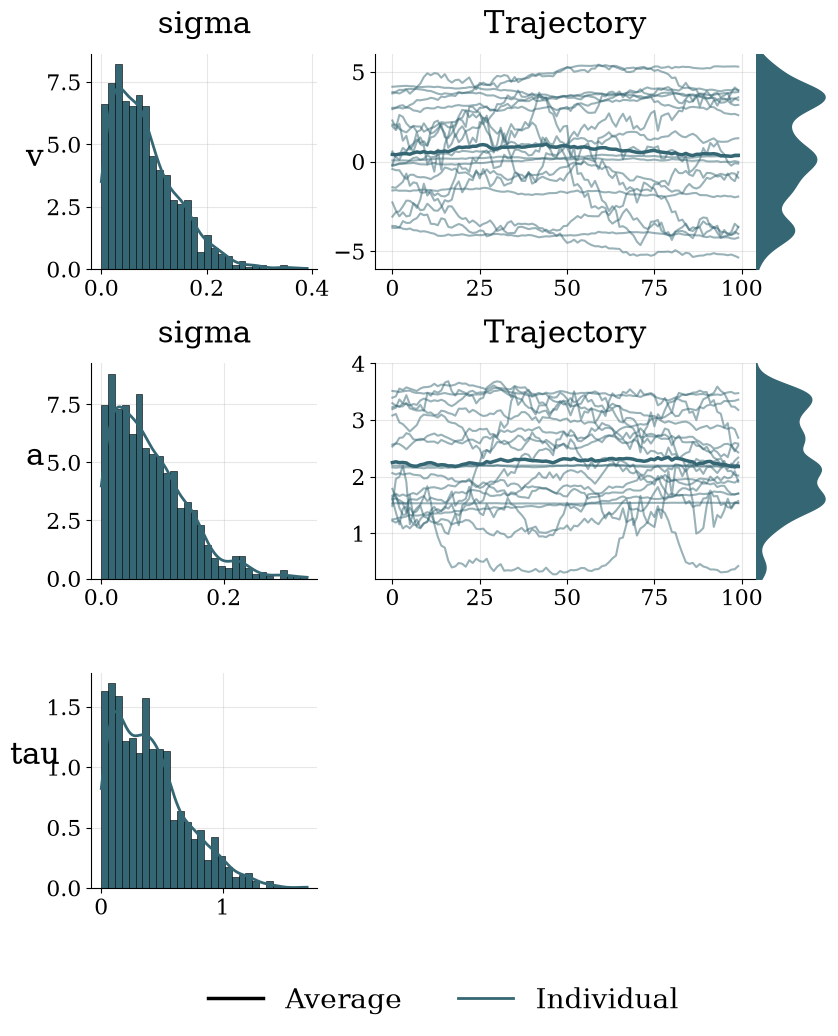

In [5]:
fig = joint_prior.plot_joint_prior(
    num_steps=NUM_STEPS,
    num_draws=1000,
    num_trajectories=20
)

## Specify a Generative Model

In [6]:
generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=obs_model,
)

In [7]:
sim_data = generative_model.sample(batch_size=10, num_steps=NUM_STEPS)

In [8]:
print(
    "Dict keys: ", sim_data.keys(), "\n",
    "Shape of response_time: ", sim_data["response_time"].shape, "\n",
    "Shape of a time-varying param: ", sim_data["v"].shape, "\n",
    "Shape of a time-invariant param: ", sim_data["v_sigma"].shape, "\n",
    sep=""
)

Dict keys: dict_keys(['response_time', 'choice', 'time_steps', 'v', 'a', 'v_sigma', 'a_sigma', 'tau'])
Shape of response_time: (10, 100)
Shape of a time-varying param: (10, 100, 1)
Shape of a time-invariant param: (10, 1)



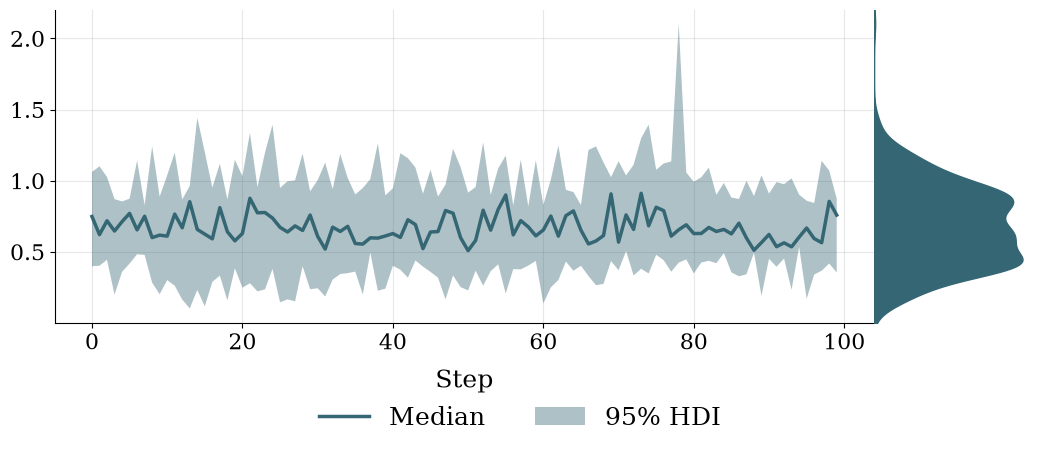

In [18]:
import numpy as np
fig = generative_model.plot_push_forward(
    num_sim=5,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="trajectory",
    aggregation=np.median,
    uncertainty_fun="95hdi",
    num_cols=4
)

In [19]:
fig.savefig("trajectory.pdf")

## Set up amortized Bayesian Workflow 

In [10]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="checkpoints/minimal_demo_v6",
    summary_network=sup.networks.RecurrentNet(),
    inference_network="coupling"
)

Here, users can provide summary and inference networks. Default networks are used if nothing is provided.

## Approximator Training

### Offline Training

Use offline training for fast iteration of the model develop and verification cicle

In [48]:
training_data = generative_model.sample(
    batch_size=10_000,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)
val_data = generative_model.sample(
    batch_size=100,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

In [24]:
history = workflow.fit_offline(
    data=training_data,
    validation_data=val_data,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - loss: 5.7388 - val_loss: 4.3837
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 3.9518 - val_loss: 3.6530
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 3.1607 - val_loss: 2.7812
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 2.8391 - val_loss: 2.4960
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 2.5914 - val_loss: 2.0957
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 2.3800 - val_loss: 2.0530
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 2.2396 - val_loss: 1.8407
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 2.1756 - val_loss: 1.8926
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 2.1066 - val_loss: 1.8304
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 2.0095 - val_loss: 1.8200
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 1.9614 - val_loss: 1.8225
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━

INFO:bayesflow:Training completed in 4.63 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'checkpoints/minimal_demo_v5/model.keras'.
To restore it:
Via the workflow: workflow.load_approximator()
Standalone: approximator = keras.saving.load_model("checkpoints/minimal_demo_v5/model.keras")


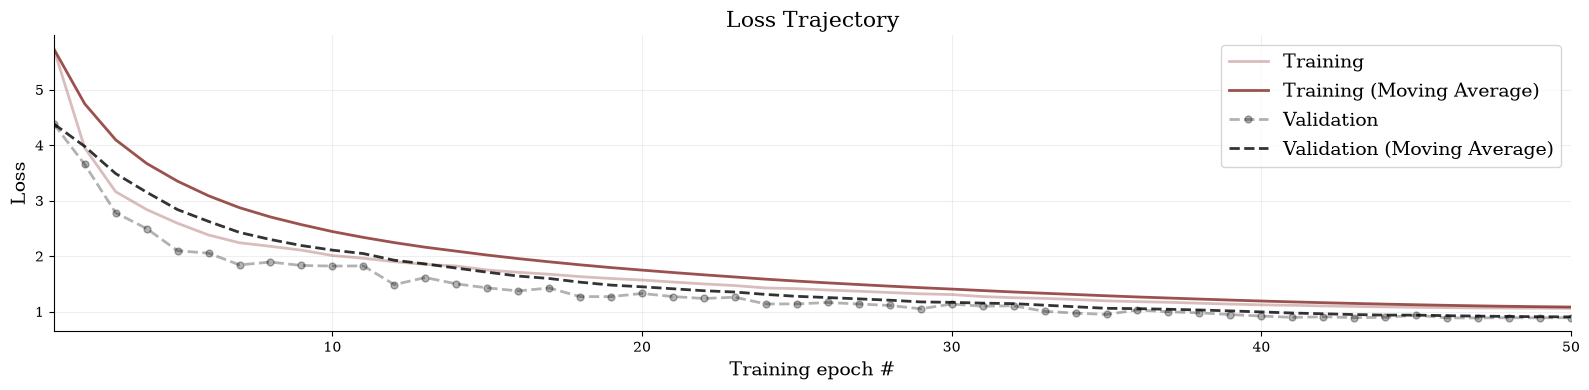

In [49]:
fig = workflow.plot_history(history)

### Online Training

Use online training for final maximal performance

In [11]:
# history = workflow.fit_online(
#     num_steps=800,
#     epochs=50,
#     num_batches_per_epoch=1000,
#     batch_size=32
# )

In [ ]:
fig = workflow.plot_history(history)

## Model Verification

Simulate some data for verification

In [12]:
targets = workflow.simulator.sample(
    batch_size=250,
    num_steps=NUM_STEPS,
)

Fit the model to the simulated data

In [14]:
samples = workflow.sample(
    data=targets,
    num_samples=300,
    batch_size=8
)

ValueError: Cannot call `forward` with `strict=False` before calling `forward` with `strict=True`.

### Time-varying Parameters

Plot four diagnostic metrics for the time-varying parameters across time:
1. Pearson correlation between true parameter and posterior median
2. Normalized root mean squared error between true parameter and posterior median
3. Posterior contraction
4. Simulation-based calibration error

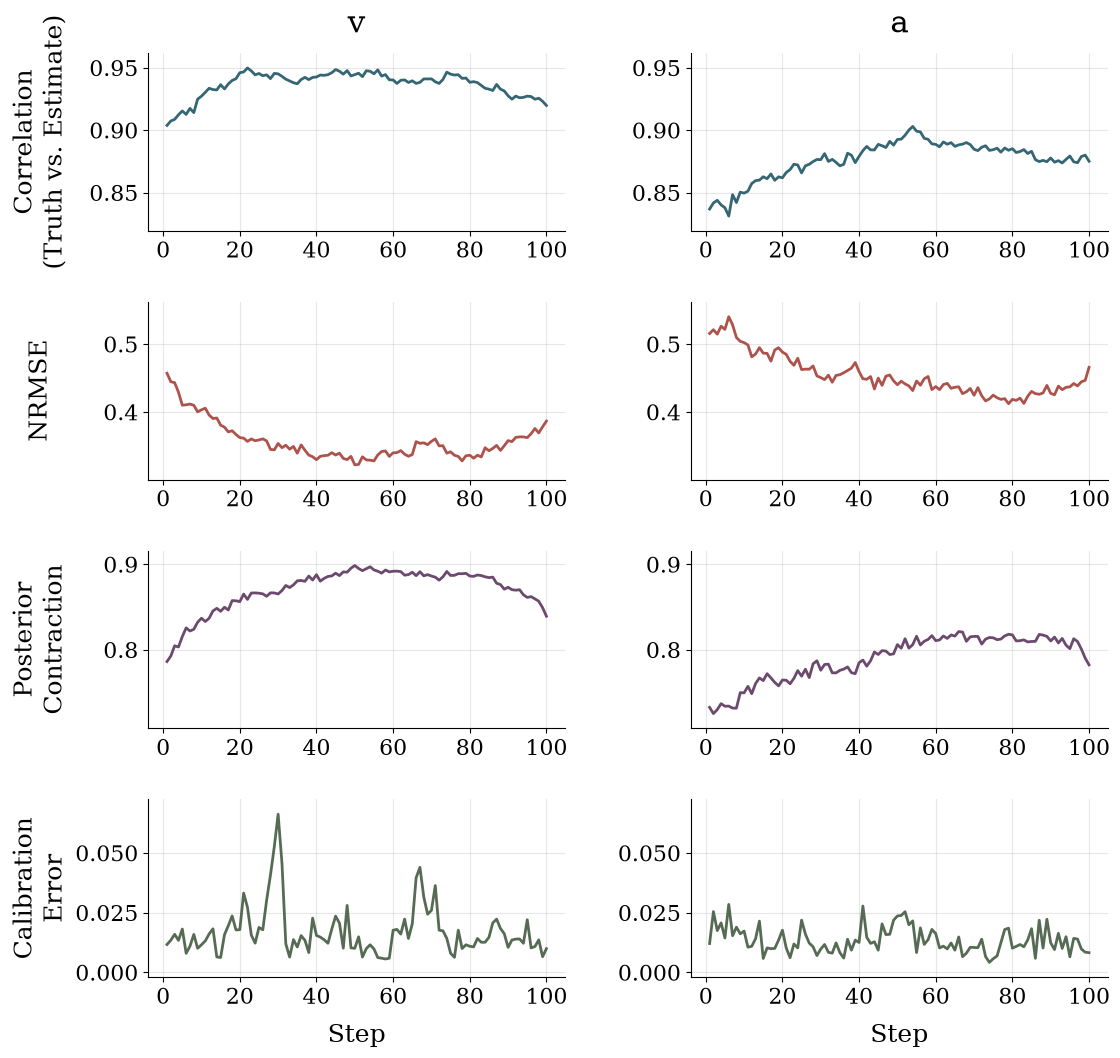

In [37]:
fig = workflow.verify_time_varying(
    targets=targets,
    estimates=samples
)

### Time-invariant Parameters

Plot recovery and simulation-based calibration for time-invariant parameters

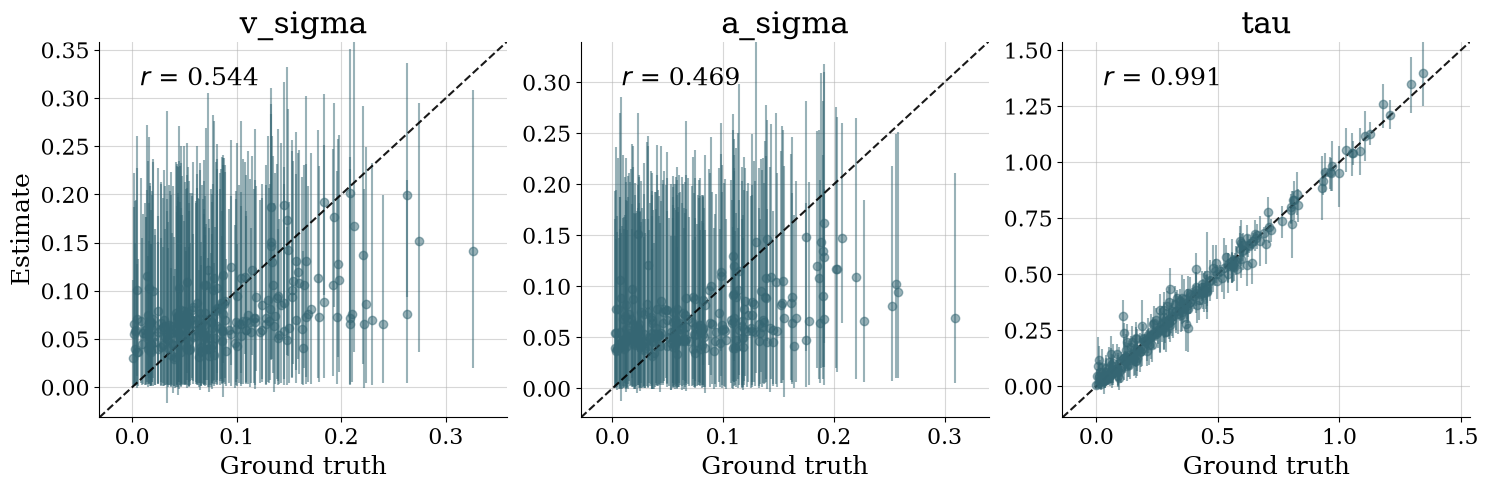

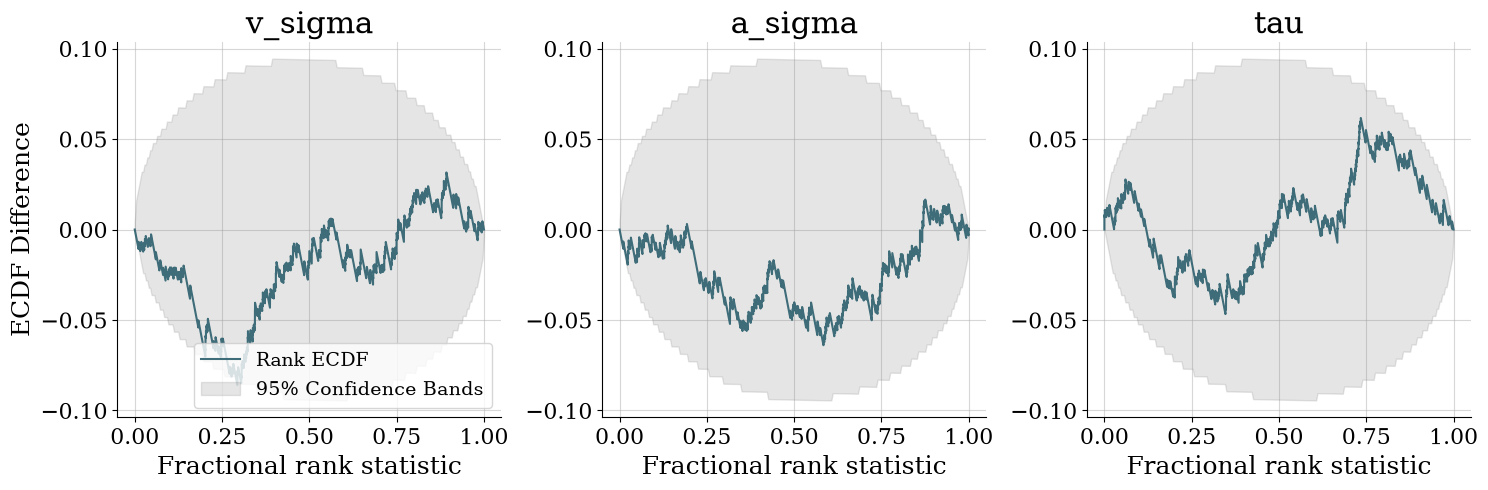

In [40]:
fig_recovery, fig_calibration = workflow.verify_time_invariant(
    estimates=samples,
    targets=targets
)

## Fit Empirical Data

The empirical data needs to be in same shape as simulated data, which means we need a `ndarray` with shape `(num_datasets, num_steps, data_dims)`.

In [3]:
df = pd.read_csv("data/data_color_discrimination.csv")
empiric_data = sup.utils.df_to_array(df, id_col="id", data_cols=("rt", "correct"))
empiric_data.shape

(14, 768, 2)

In [ ]:
samples = workflow.sample(
    data=empiric_data,
    num_samples=500
)

## Posterior Re-simulation

## Posterior Estimates